1. Optimization Framework Objective:



Minimize the Mahalanobis distance between the optimized shock vector 

opt and the original ISDA shock vector , subject to realistic constraints.



Constraints:


Rank Preservation: Sectors must maintain their relative risk order (Mining > Transport > Finance, etc.)

Regional Pattern Preservation: Asia ≥ US ≥ Europe for same sector (where applicable)

Direction Consistency: All shocks remain negative (no sign flips)


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [42]:
# Define the ETFs based on our mapping
etfs = {
    # Europe ETFs
    'EUR_MINING': 'EXV6.DE',  # iShares STOXX Europe 600 Basic Resources - Since Jan 2008
    'EUR_TRANSPORT': 'EXV9.DE',  # UiShares STOXX Europe 600 Travel & Leisure - Since Jan 2008
    'EUR_UTILITIES': 'EXH9.DE',  # iShares STOXX Europe 600 Utilities - Since Jan 2008
    'EUR_CHEMICALS': 'EXV7.DE',  # iShares STOXX Europe 600 Chemicals - Since Jan 2008
    'EUR_FINANCE': 'EXV1.DE',  # iShares STOXX Europe 600 Banks - Since Jan 2008
    
    # US ETFs
    'US_MINING': 'XME',  # State Street SPDR S&P Metals & Mining ETF - Since 2006
    'US_TRANSPORT': 'IYT',  # iShares Transportation Average ETF - Since Jan 2004
    'US_UTILITIES': 'XLU',  # Utilities Select Sector SPDR - Since Jan 1999
    'US_CHEMICALS': 'IYM',  # iShares U.S. Basic Materials - Since Jun 2000 
    'US_FINANCE': 'XLF',  # Financial Select Sector SPDR - Since Jan 1999


    # Asia ETFs (using China as proxy)
    'ASIA_MINING': 'CHIM',  # Global X MSCI China Materials ETF
    'ASIA_TRANSPORT': '1628.T',  # NEXT FUNDS TOPIX-17 TRANSPORTATION & LOGISTICS ETF - Since Apr 2008
    'ASIA_UTILITIES': '^107570-USD-STRD',  # MSCI AC ASIA/UTILITIES - Since Jan 1999
    'ASIA_CHEMICALS': '^107541-USD-STRD',  # MSCI AC ASIA/MATERIALS - Since Jan 1999 
    'ASIA_FINANCE': '^107515-USD-STRD',  # MSCI AC ASIA/FINANCIALS - Since Jan 1999
}

In [43]:
# Original ISDA shocks (as decimals) 1 Year shocks
original_shocks = {
    'EUR_MINING': -0.35,
    'EUR_TRANSPORT': -0.30,
    'EUR_UTILITIES': -0.30,
    'EUR_CHEMICALS': -0.30,
    'EUR_FINANCE': -0.15,
    
    'US_MINING': -0.40,
    'US_TRANSPORT': -0.30,
    'US_UTILITIES': -0.30,
    'US_CHEMICALS': -0.30,
    'US_FINANCE': -0.20,
    
    'ASIA_MINING': -0.60,
    'ASIA_TRANSPORT': -0.35,
    'ASIA_UTILITIES': -0.35,
    'ASIA_CHEMICALS': -0.35,
    'ASIA_FINANCE': -0.20,
}

In [44]:
# Create ordered list of ETF keys

etf_order = list(original_shocks.keys())
n_etfs = len(etf_order)

In [45]:
# Get historical data (Feb 2024 - Feb 2025)
end_date = "2025-11-29"
start_date = "2015-11-29"

In [46]:
print("Fetching 10 historical data for ETFs...")
print("=" * 60)

# Download data
returns_data = {}
for name, ticker in etfs.items():
    try:
        data = yf.download(ticker, start=start_date, end=end_date)
        if len(data) > 0:
            # Calculate rolling weekly returns (5 trading days)
            returns = data['Close'].pct_change(periods=5).dropna()
            returns_data[name] = returns
            print(f"✓ {name}: {ticker} - {len(returns)} trading days")
        else:
            print(f"✗ {name}: {ticker} - No data available")
    except Exception as e:
        print(f"✗ {name}: {ticker} - Error: {str(e)[:50]}...")

print("\n" + "=" * 60)

Fetching 10 historical data for ETFs...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


✓ EUR_MINING: EXV6.DE - 2536 trading days
✓ EUR_TRANSPORT: EXV9.DE - 2536 trading days


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


✓ EUR_UTILITIES: EXH9.DE - 2536 trading days
✓ EUR_CHEMICALS: EXV7.DE - 2536 trading days
✓ EUR_FINANCE: EXV1.DE - 2536 trading days


...

✓ US_MINING: XME - 2510 trading days
✓ US_TRANSPORT: IYT - 2510 trading days
✓ US_UTILITIES: XLU - 2510 trading days



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


✓ US_CHEMICALS: IYM - 2510 trading days
✓ US_FINANCE: XLF - 2510 trading days
✓ ASIA_MINING: CHIM - 2074 trading days


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

✓ ASIA_TRANSPORT: 1628.T - 2458 trading days
✓ ASIA_UTILITIES: ^107570-USD-STRD - 2510 trading days
✓ ASIA_CHEMICALS: ^107541-USD-STRD - 2510 trading days
✓ ASIA_FINANCE: ^107515-USD-STRD - 2510 trading days



In [47]:
# Combine returns into a DataFrame (robust)
if not returns_data:
    raise ValueError("returns_data is empty: no ETF data was downloaded / no returns computed.")
returns_df = pd.concat(returns_data, axis=1)  # columns are dict keys
returns_df = returns_df[etf_order]  # Ensure correct order
returns_df.dropna(inplace=True)  # Drop rows with any NaN values
print(f"Combined returns DataFrame shape: {returns_df.shape}")

Combined returns DataFrame shape: (1931, 15)


In [48]:

returns_df = pd.concat(returns_data, axis=1)  # columns are dict keys

# create a data frame considering a levels ase 100
levels_df = (1 + returns_df).cumprod() * 100
levels_df = levels_df[etf_order]  # Ensure correct order
levels_df.dropna(inplace=True)  # Drop rows with any NaN values

# make levels_df a dataframe
levels_df = pd.DataFrame(levels_df)
levels_df.head()

,EUR_MINING,EUR_TRANSPORT,EUR_UTILITIES,EUR_CHEMICALS,EUR_FINANCE,US_MINING,US_TRANSPORT,US_UTILITIES,US_CHEMICALS,US_FINANCE,ASIA_MINING,ASIA_TRANSPORT,ASIA_UTILITIES,ASIA_CHEMICALS,ASIA_FINANCE
Ticker,EXV6.DE,EXV9.DE,EXH9.DE,EXV7.DE,EXV1.DE,XME,IYT,XLU,IYM,XLF,CHIM,1628.T,^107570-USD-STRD,^107541-USD-STRD,^107515-USD-STRD
Date,,,,,,,,,,,,,,,
2015-12-07,92.122065,100.195236,97.539923,93.732509,96.779126,96.144257,97.237675,99.626357,98.206084,99.959287,103.256571,98.630658,100.560513,100.242945,100.798852
2015-12-08,79.589796,98.098117,93.251773,88.862934,90.713490,89.155143,90.816218,98.333685,93.861251,97.584115,102.409954,97.479981,97.934109,96.376895,98.816705
2015-12-09,70.736932,94.178705,89.794716,83.986201,85.082991,85.431068,86.235511,99.289047,93.950562,95.277695,97.608254,95.575016,95.274689,92.975636,96.345793
2015-12-10,66.706283,92.993153,88.855109,82.472221,81.883370,84.574107,83.872981,99.360159,93.912057,94.646142,93.560711,94.023133,93.207762,89.610597,93.695908
2015-12-11,60.715948,90.475874,86.785992,79.655786,76.956919,79.811592,79.383057,97.769273,89.938931,89.566219,88.017173,92.906968,91.660458,88.182808,91.429077


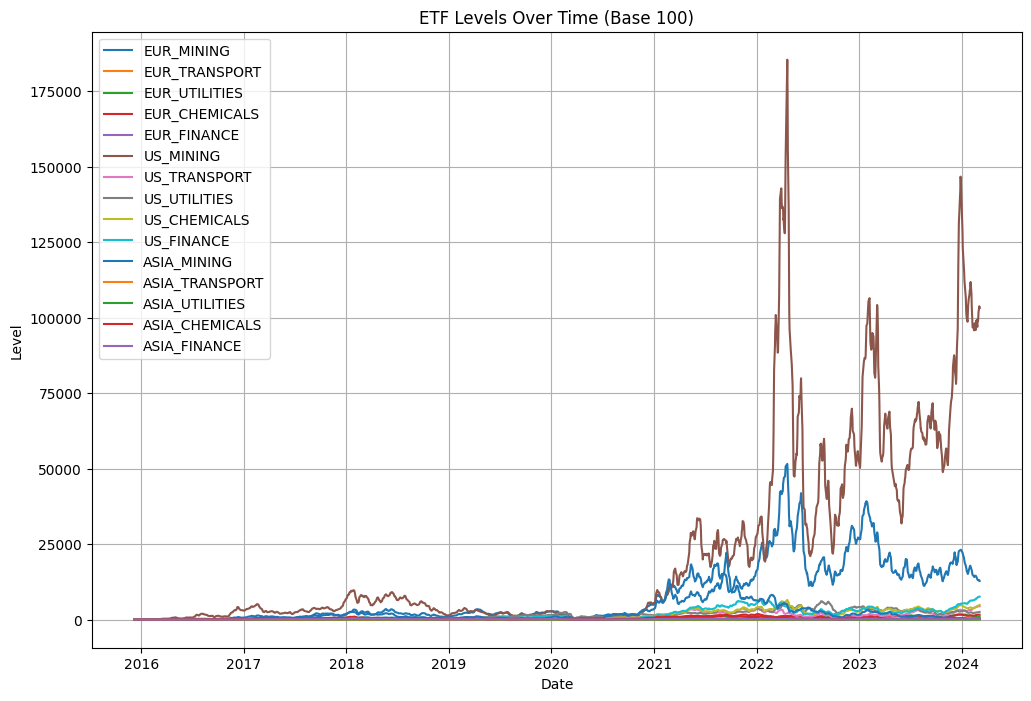

In [49]:
# plot levels_df
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for etf in etf_order:
    plt.plot(levels_df.index, levels_df[etf], label=etf)
plt.title("ETF Levels Over Time (Base 100)")
plt.xlabel("Date")
plt.ylabel("Level")
plt.legend()
plt.grid()
plt.show()

In [50]:
# Align all return series to common dates
common_dates = None
for name, returns in returns_data.items():
    if common_dates is None:
        common_dates = returns.index
    else:
        common_dates = common_dates.intersection(returns.index)

In [51]:
# Create aligned returns DataFrame
aligned_returns = pd.DataFrame(index=common_dates)
for name in etf_order:
    if name in returns_data:
        aligned_returns[name] = returns_data[name].reindex(common_dates)
    else:
        # Fill missing with NaN (will be handled later)
        aligned_returns[name] = np.nan

print(f"\nCommon trading days: {len(aligned_returns)}")
print(f"Available ETFs: {aligned_returns.dropna(axis=1).shape[1]} out of {n_etfs}")


Common trading days: 1931
Available ETFs: 15 out of 15


In [52]:
# Fill missing data with forward fill then backward fill if needed
aligned_returns = aligned_returns.ffill().bfill()

In [53]:
# Calculate covariance matrix
cov_matrix = aligned_returns.cov()
inv_cov_matrix = np.linalg.inv(cov_matrix)

print(f"\nCovariance matrix shape: {cov_matrix.shape}")
print(f"Condition number: {np.linalg.cond(cov_matrix):.2f}")


Covariance matrix shape: (15, 15)
Condition number: 131.83


In [54]:
# Calculate original Mahalanobis distance
s_orig = np.array([original_shocks[etf] for etf in etf_order])
original_mahalanobis = np.sqrt(s_orig.T @ inv_cov_matrix @ s_orig)
print(f"\nOriginal Mahalanobis Distance: {original_mahalanobis:.4f}")


Original Mahalanobis Distance: 27.1441


In [56]:
 #Define optimization constraints
def objective(s_opt):
    """Minimize Mahalanobis distance from original shocks"""
    diff = s_opt - s_orig
    return np.sqrt(diff.T @ inv_cov_matrix @ diff)

In [57]:
# Define constraints
constraints = []

In [74]:
# 1. All shocks must be negative (or zero)
#for i in range(n_etfs):
#    constraints.append({'type': 'ineq', 'fun': lambda x, i=i: -x[i]})

# 2. Regional ordering constraints (Asia ≥ US ≥ Europe for same sector)
sector_indices = {
    'MINING': [etf_order.index('EUR_MINING'), etf_order.index('US_MINING'), etf_order.index('ASIA_MINING')],
    'TRANSPORT': [etf_order.index('EUR_TRANSPORT'), etf_order.index('US_TRANSPORT'), etf_order.index('ASIA_TRANSPORT')],
    'UTILITIES': [etf_order.index('EUR_UTILITIES'), etf_order.index('US_UTILITIES'), etf_order.index('ASIA_UTILITIES')],
    'CHEMICALS': [etf_order.index('EUR_CHEMICALS'), etf_order.index('US_CHEMICALS'), etf_order.index('ASIA_CHEMICALS')],
    'FINANCE': [etf_order.index('EUR_FINANCE'), etf_order.index('US_FINANCE'), etf_order.index('ASIA_FINANCE')],
}

for sector, indices in sector_indices.items():
    # Asia ≥ US
    constraints.append({'type': 'ineq', 'fun': lambda x, idx=indices: x[idx[2]] - x[idx[1]]})
    # US ≥ Europe
    constraints.append({'type': 'ineq', 'fun': lambda x, idx=indices: x[idx[1]] - x[idx[0]]})

# 3. Sector ordering constraints (within each region)
for region in ['EUR', 'US', 'ASIA']:
    region_etfs = [etf for etf in etf_order if etf.startswith(region)]
    region_indices = [etf_order.index(etf) for etf in region_etfs]
    
    # Get sector types for this region
    sectors = []
    for etf in region_etfs:
        sector = etf.split('_')[1]
        if sector not in sectors:
            sectors.append(sector)
    
    # Define sector severity order: MINING > TRANSPORT/UTILITIES/CHEMICALS > FINANCE
    if 'MINING' in sectors and 'TRANSPORT' in sectors:
        min_idx = region_etfs.index(f"{region}_MINING")
        trans_idx = region_etfs.index(f"{region}_TRANSPORT")
        constraints.append({'type': 'ineq', 'fun': lambda x, min_i=region_indices[min_idx], trans_i=region_indices[trans_idx]: x[trans_i] - x[min_i]})
    
    if 'TRANSPORT' in sectors and 'FINANCE' in sectors:
        trans_idx = region_etfs.index(f"{region}_TRANSPORT")
        fin_idx = region_etfs.index(f"{region}_FINANCE")
        constraints.append({'type': 'ineq', 'fun': lambda x, trans_i=region_indices[trans_idx], fin_i=region_indices[fin_idx]: x[fin_i] - x[trans_i]})

# 4. Bounds: shocks within +15% of original values
bounds = [(original_shocks[etf] - 0, min(0, original_shocks[etf] + 0.15)) for etf in etf_order]
print(f"\nStarting optimization with {len(constraints)} constraints...")



Starting optimization with 140 constraints...


In [75]:
# Run optimization
result = minimize(objective, x0=s_orig, bounds=bounds, constraints=constraints, 
                  method='SLSQP', options={'maxiter': 1000, 'ftol': 1e-8})

if result.success:
    optimized_shocks = result.x
    optimized_mahalanobis = result.fun
    
    print(f"✓ Optimization successful!")
    print(f"Optimized Mahalanobis Distance: {optimized_mahalanobis:.4f}")
    print(f"Improvement: {(1 - optimized_mahalanobis/original_mahalanobis)*100:.1f}% reduction")

In [76]:
# Create results DataFrame
results_df = pd.DataFrame({
        'ETF': etf_order,
        'Ticker': [etfs[etf] for etf in etf_order],
        'Original_Shock': [f"{s*100:.1f}%" for s in s_orig],
        'Optimized_Shock': [f"{s*100:.1f}%" for s in optimized_shocks],
        'Change': [f"{(s2-s1)*100:+.1f}%" for s1, s2 in zip(s_orig, optimized_shocks)],
        'Abs_Change': [f"{abs((s2-s1)/s1)*100:.1f}%" for s1, s2 in zip(s_orig, optimized_shocks)]
    })
    
print("\n" + "=" * 80)
print("OPTIMIZATION RESULTS")
print("=" * 80)


OPTIMIZATION RESULTS


In [77]:
# Display by region
for region in ['EUR', 'US', 'ASIA']:
        region_df = results_df[results_df['ETF'].str.startswith(region)].copy()
        print(f"\n{region} REGION:")
        print("-" * 60)
        print(region_df.to_string(index=False))


EUR REGION:
------------------------------------------------------------
          ETF  Ticker Original_Shock Optimized_Shock Change Abs_Change
   EUR_MINING EXV6.DE         -35.0%          -50.0% -15.0%      42.9%
EUR_TRANSPORT EXV9.DE         -30.0%          -39.1%  -9.1%      30.4%
EUR_UTILITIES EXH9.DE         -30.0%          -36.4%  -6.4%      21.2%
EUR_CHEMICALS EXV7.DE         -30.0%          -37.1%  -7.1%      23.7%
  EUR_FINANCE EXV1.DE         -15.0%          -26.7% -11.7%      78.0%

US REGION:
------------------------------------------------------------
         ETF Ticker Original_Shock Optimized_Shock Change Abs_Change
   US_MINING    XME         -40.0%          -50.0% -10.0%      25.0%
US_TRANSPORT    IYT         -30.0%          -37.3%  -7.3%      24.5%
US_UTILITIES    XLU         -30.0%          -34.6%  -4.6%      15.3%
US_CHEMICALS    IYM         -30.0%          -37.1%  -7.1%      23.7%
  US_FINANCE    XLF         -20.0%          -26.7%  -6.7%      33.5%

ASIA REGION: